In [3]:
from path_config import PathConfig
import pandas as pd

# Yapılandırmayı başlat
config = PathConfig()

# Sayfa adı (daha okunur ve risksiz)
sheet_name = "Series Formatted Data"

# DL dosyalarını oku ve birleştir
df_dl = pd.concat(
    [
        pd.read_excel(config.dl_path, sheet_name=sheet_name),
        pd.read_excel(config.test_dl_path, sheet_name=sheet_name)
    ],
    ignore_index=True,
    join='outer'
)

# UL dosyalarını oku ve birleştir
df_ul = pd.concat(
    [
        pd.read_excel(config.ul_path, sheet_name=sheet_name),
        pd.read_excel(config.test_ul_path, sheet_name=sheet_name)
    ],
    ignore_index=True,
    join='outer'
)

# Scanner dosyalarını oku ve birleştir
df_scanner = pd.concat(
    [
        pd.read_excel(config.scanner_path, sheet_name=sheet_name),
        pd.read_excel(config.test_scanner_path, sheet_name=sheet_name)
    ],
    ignore_index=True,
    join='outer'
)

# Sütun isimlerini yazdır (kontrol için)
print("DL Columns:", df_dl.columns.tolist())
print("UL Columns:", df_ul.columns.tolist())
print("Scanner Columns:", df_scanner.columns.tolist())


DL Columns: ['Message', 'Time', 'Longitude', 'Latitude', 'Technology_Mode', 'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0', 'NR_UE_Nbr_PCI_0', 'NR_UE_Nbr_PCI_1', 'NR_UE_Nbr_PCI_2', 'NR_UE_Nbr_PCI_3', 'NR_UE_Nbr_PCI_4', 'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_RSRP_1', 'NR_UE_Nbr_RSRP_2', 'NR_UE_Nbr_RSRP_3', 'NR_UE_Nbr_RSRP_4', 'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRQ_1', 'NR_UE_Nbr_RSRQ_2', 'NR_UE_Nbr_RSRQ_3', 'NR_UE_Nbr_RSRQ_4', 'NR_UE_Timing_Advance', 'NR_UE_Pathloss_DL_0', 'NR_UE_Throughput_PDCP_DL', 'App_Throughput_DL', 'NR_UE_NACK_Rate_DL_0', 'NR_UE_Ack_As_Nack_DL_0', 'NR_UE_MCS_DL_0', 'NR_UE_RB_Num_DL_0', 'NR_UE_Modulation_Avg_DL_0', 'NR_UE_RI_DL_0', 'NR_UE_BLER_DL_0', 'NR_UE_CCE_AggregationLev_0', 'NR_UE_Power_Tx_PUSCH_0', 'NR_UE_Power_Tx_PRACH_0', 'NR_UE_NACK_Rate_UL_0', 'NR_UE_RACH_Attempt', 'NR_UE_RACH_OK', 'NR_UE_RACH_Fail', 'NR_UE_RACH_Procedure_Count', 'NR_UE_RRCReEstAttempt', 'NR_UE_RRCReEstFail', 'NR_UE_RRCReEst_EndResult', 'NR_UE_RRCConnectionAttempt', 'NR_UE_RRCConnect

In [4]:
# DL için kullanılacak sütunlar
dl_columns = [
    "Time", "Longitude", "Latitude",
    "NR_UE_RACH_Attempt", "NR_UE_RACH_OK", "NR_UE_RACH_Fail", "NR_UE_RACH_Procedure_Count",
    "NR_UE_RRCReEstAttempt", "NR_UE_RRCReEstFail", "NR_UE_RRCReEst_EndResult",
    "NR_UE_RRCConnectionAttempt", "NR_UE_RRCConnectionSetupOk", "NR_UE_RRCConnectionComplete",
    "NR_UE_RRCConnectionDrop", "NR_UE_RRCHOAttempt", "NR_UE_RRCHOOK",
    "NR_RRC_MsgType", "NAS_5GS_MM_MessageType", "NAS_5GS_SM_MessageType"
]

# df_dl içinde bulunan sütunlarla kesişimini al (eksik olanlar varsa atla)
filtered_df_dl = df_dl[[col for col in dl_columns if col in df_dl.columns]]

# Kontrol amaçlı sütunları yazdır
print(filtered_df_dl.columns.tolist())


['Time', 'Longitude', 'Latitude', 'NR_UE_RACH_Attempt', 'NR_UE_RACH_OK', 'NR_UE_RACH_Fail', 'NR_UE_RACH_Procedure_Count', 'NR_UE_RRCReEstAttempt', 'NR_UE_RRCReEstFail', 'NR_UE_RRCReEst_EndResult', 'NR_UE_RRCConnectionAttempt', 'NR_UE_RRCConnectionSetupOk', 'NR_UE_RRCConnectionComplete', 'NR_UE_RRCConnectionDrop', 'NR_UE_RRCHOAttempt', 'NR_UE_RRCHOOK', 'NR_RRC_MsgType', 'NAS_5GS_MM_MessageType', 'NAS_5GS_SM_MessageType']


In [5]:
# İlk 3 sütunu dışla
columns_to_check = filtered_df_dl.columns[3:]

# Her kolon için değer sayımını yazdır
for col in columns_to_check:
    print(f"\n--- {col} ---")
    value_counts = filtered_df_dl[col].value_counts(dropna=False)
    for value, count in value_counts.items():
        print(f"{value}: {count}")



--- NR_UE_RACH_Attempt ---
0: 215846
1: 57

--- NR_UE_RACH_OK ---
0: 215849
1: 54

--- NR_UE_RACH_Fail ---
nan: 143423
0.0: 72477
1.0: 3

--- NR_UE_RACH_Procedure_Count ---
nan: 215846
9.0: 2
1.0: 2
16.0: 2
15.0: 2
13.0: 2
12.0: 2
11.0: 2
10.0: 2
14.0: 2
8.0: 2
6.0: 2
5.0: 2
4.0: 2
3.0: 2
7.0: 2
2.0: 2
35.0: 1
31.0: 1
32.0: 1
33.0: 1
34.0: 1
38.0: 1
36.0: 1
37.0: 1
39.0: 1
40.0: 1
29.0: 1
30.0: 1
21.0: 1
28.0: 1
27.0: 1
26.0: 1
25.0: 1
24.0: 1
23.0: 1
22.0: 1
20.0: 1
19.0: 1
18.0: 1
17.0: 1
41.0: 1

--- NR_UE_RRCReEstAttempt ---
nan: 143423
0.0: 72479
1.0: 1

--- NR_UE_RRCReEstFail ---
nan: 143423
0.0: 72479
1.0: 1

--- NR_UE_RRCReEst_EndResult ---
nan: 215902
Re-establishment failure after Request: 1

--- NR_UE_RRCConnectionAttempt ---
nan: 143423
0.0: 72474
1.0: 6

--- NR_UE_RRCConnectionSetupOk ---
nan: 143423
0.0: 72474
1.0: 6

--- NR_UE_RRCConnectionComplete ---
nan: 143423
0.0: 72478
1.0: 2

--- NR_UE_RRCConnectionDrop ---
nan: 143423
0.0: 72476
1.0: 4

--- NR_UE_RRCHOAttempt --

/var/folders/01/_bgw0fxs5rv8ysw_gs46q0v40000gn/T/ipykernel_9107/2822932219.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", plot_df.shape[1])


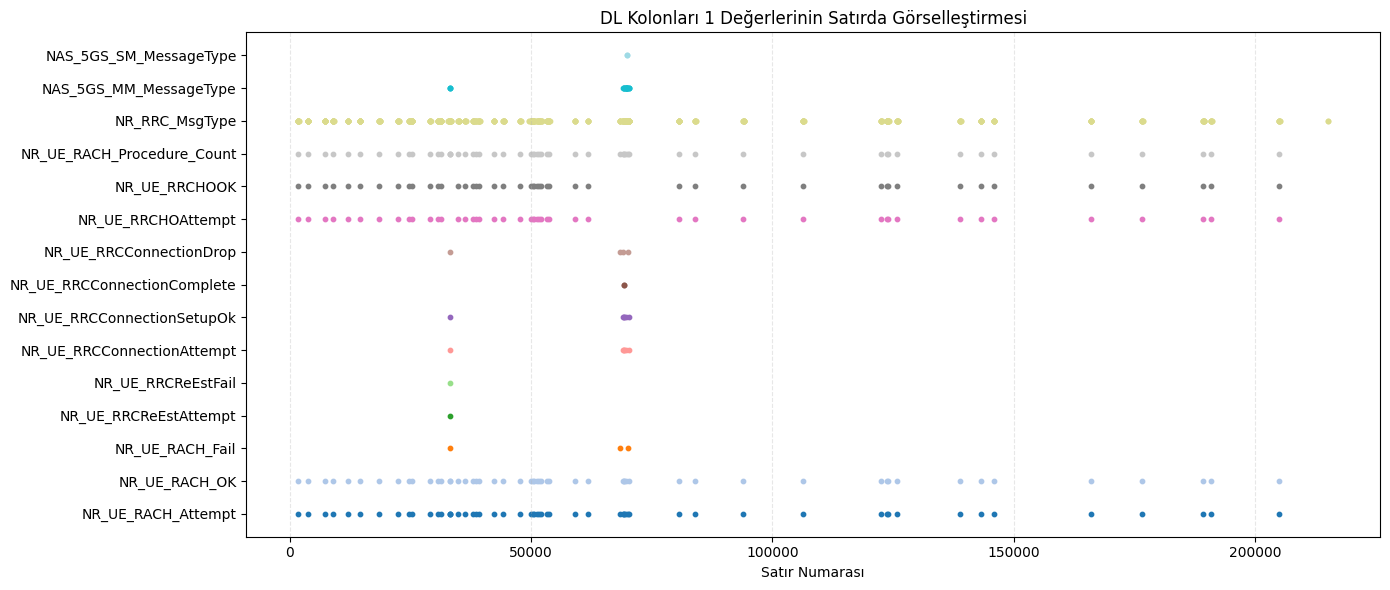

In [6]:
import matplotlib.pyplot as plt

# İlk 3 sütun grafiğe dahil edilmesin
excluded_cols = ["Time", "Longitude", "Latitude"]

binary_cols = [
    "NR_UE_RACH_Attempt", "NR_UE_RACH_OK", "NR_UE_RACH_Fail",
    "NR_UE_RRCReEstAttempt", "NR_UE_RRCReEstFail", "NR_UE_RRCReEst_EndResult",
    "NR_UE_RRCConnectionAttempt",
    "NR_UE_RRCConnectionSetupOk", "NR_UE_RRCConnectionComplete",
    "NR_UE_RRCConnectionDrop", "NR_UE_RRCHOAttempt", "NR_UE_RRCHOOK"
]

other_cols = [col for col in filtered_df_dl.columns if col not in excluded_cols + binary_cols]

plot_df = pd.DataFrame(index=filtered_df_dl.index)

# Binary sütunları ekle
for col in binary_cols:
    if col in filtered_df_dl.columns:
        plot_df[col] = pd.to_numeric(filtered_df_dl[col], errors='coerce').fillna(0).astype(int)

# Diğer sütunlar için NaN değilse 1
for col in other_cols:
    plot_df[col] = (~filtered_df_dl[col].isna()).astype(int)

# Tümü sıfır olan kolonları at
plot_df = plot_df.loc[:, (plot_df.sum(axis=0) > 0)]

# --- SCATTER GRAFİK ---
plt.figure(figsize=(14, 6))

cmap = plt.cm.get_cmap("tab20", plot_df.shape[1])
colors = [cmap(i) for i in range(plot_df.shape[1])]

for i, col in enumerate(plot_df.columns):
    ones_index = plot_df.index[plot_df[col] == 1]
    plt.scatter(ones_index, [i] * len(ones_index), label=col, color=colors[i], s=10)

plt.yticks(range(len(plot_df.columns)), plot_df.columns)
plt.xlabel("Satır Numarası")
plt.title("DL Kolonları 1 Değerlerinin Satırda Görselleştirmesi")
plt.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/01/_bgw0fxs5rv8ysw_gs46q0v40000gn/T/ipykernel_9107/1338387063.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", plot_df.shape[1])


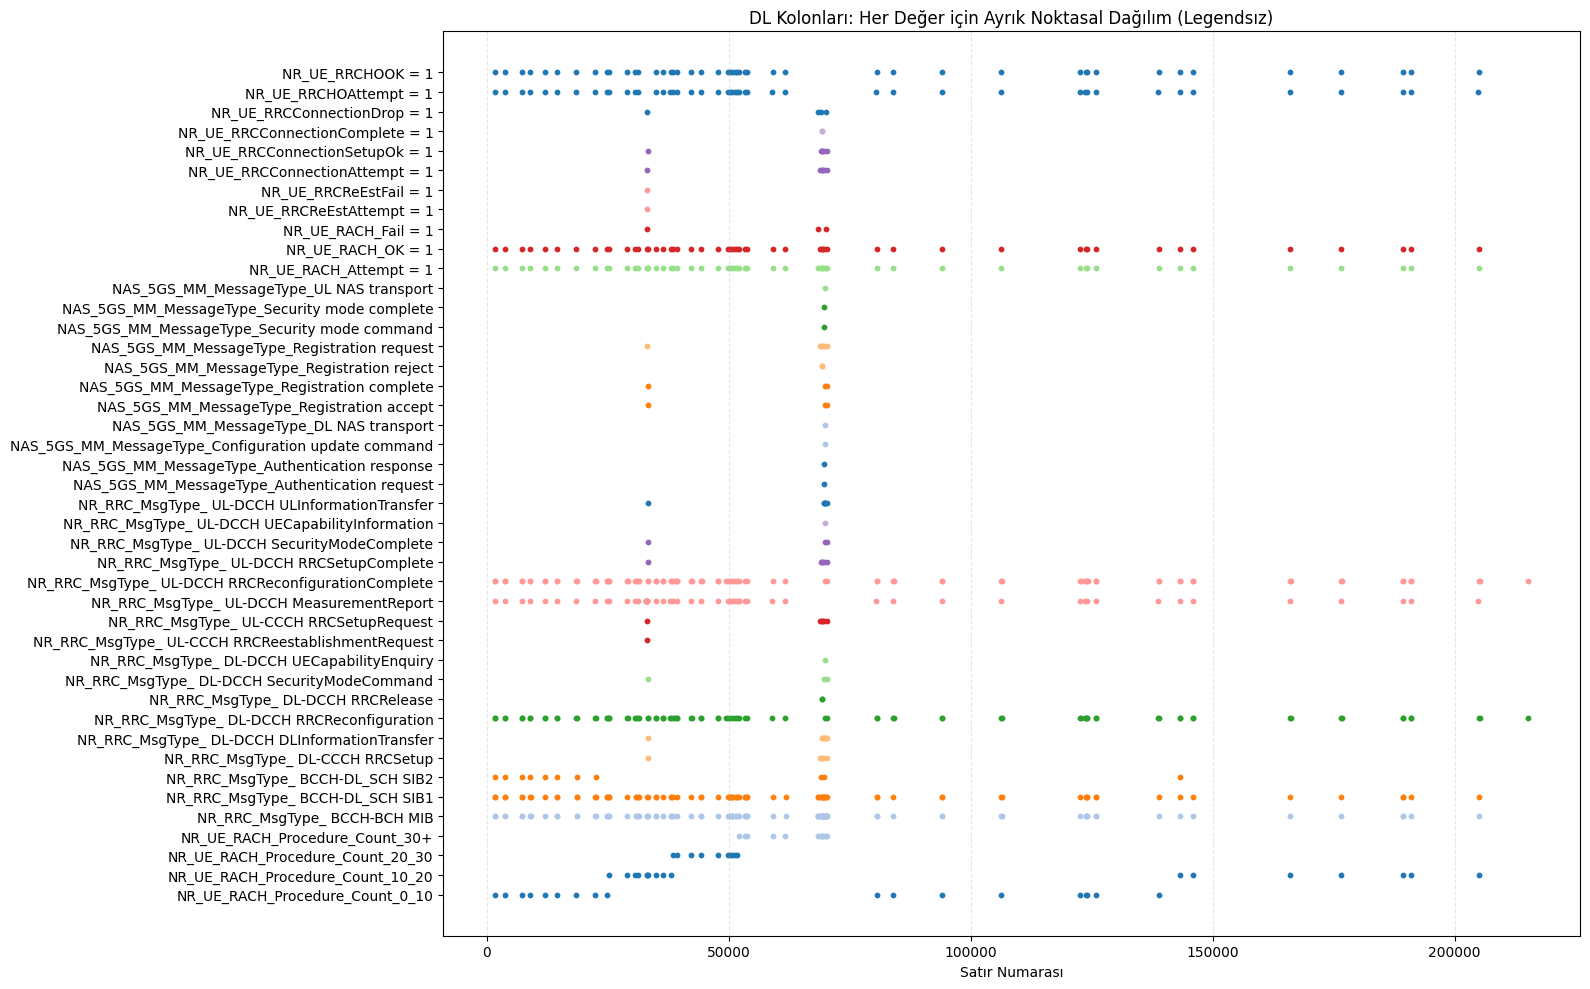

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# İlk 3 sütun grafiğe dahil edilmesin
excluded_cols = ["Time", "Longitude", "Latitude"]

# Özel işlenecek kolonlar
categorical_cols = ["NR_RRC_MsgType", "NAS_5GS_MM_MessageType"]
binned_col = "NR_UE_RACH_Procedure_Count"

# Yeni plot veri çerçevesi
plot_df = pd.DataFrame(index=filtered_df_dl.index)

# --- 1) NR_UE_RACH_Procedure_Count için binleme ---
if binned_col in filtered_df_dl.columns:
    rach_col = pd.to_numeric(filtered_df_dl[binned_col], errors='coerce')
    plot_df[f"{binned_col}_0_10"]   = ((rach_col >= 0) & (rach_col < 10)).astype(int)
    plot_df[f"{binned_col}_10_20"]  = ((rach_col >= 10) & (rach_col < 20)).astype(int)
    plot_df[f"{binned_col}_20_30"]  = ((rach_col >= 20) & (rach_col < 30)).astype(int)
    plot_df[f"{binned_col}_30+"]    = (rach_col >= 30).astype(int)

# --- 2) Categorical kolonları one-hot encode et ---
for col in categorical_cols:
    if col in filtered_df_dl.columns:
        dummies = pd.get_dummies(filtered_df_dl[col], prefix=col)
        plot_df = pd.concat([plot_df, dummies], axis=1)

# --- 3) Diğer kolonlar: sadece 1 olanları binary olarak ekle ---
for col in filtered_df_dl.columns:
    if col not in excluded_cols + categorical_cols + [binned_col]:
        numeric_col = pd.to_numeric(filtered_df_dl[col], errors='coerce')
        binary_series = (numeric_col == 1).astype(int)
        if binary_series.sum() > 0:
            plot_df[col + " = 1"] = binary_series

# --- 4) Tamamen boş kolonları at ---
plot_df = plot_df.loc[:, plot_df.sum(axis=0) > 0]

# --- 5) SCATTER GRAFİK (LEGENDSIZ) ---
plt.figure(figsize=(16, 10))

cmap = plt.cm.get_cmap("tab20", plot_df.shape[1])
colors = [cmap(i % 20) for i in range(plot_df.shape[1])]

for i, col in enumerate(plot_df.columns):
    indices = plot_df.index[plot_df[col] == 1]
    plt.scatter(indices, [i] * len(indices), s=10, color=colors[i])

plt.yticks(range(len(plot_df.columns)), plot_df.columns)
plt.xlabel("Satır Numarası")
plt.title("DL Kolonları: Her Değer için Ayrık Noktasal Dağılım (Legendsız)")
plt.grid(True, axis='x', linestyle='--', alpha=0.3)

# Legend satırı KALDIRILDI
# plt.legend(...)

plt.tight_layout()
plt.show()


In [8]:
# UL için kullanılacak sütunlar (aynı DL ile)
ul_columns = [
    "Time", "Longitude", "Latitude",
    "NR_UE_RACH_Attempt", "NR_UE_RACH_OK", "NR_UE_RACH_Fail", "NR_UE_RACH_Procedure_Count",
    "NR_UE_RRCReEstAttempt", "NR_UE_RRCReEstFail", "NR_UE_RRCReEst_EndResult",
    "NR_UE_RRCConnectionAttempt", "NR_UE_RRCConnectionSetupOk", "NR_UE_RRCConnectionComplete",
    "NR_UE_RRCConnectionDrop", "NR_UE_RRCHOAttempt", "NR_UE_RRCHOOK",
    "NR_RRC_MsgType", "NAS_5GS_MM_MessageType", "NAS_5GS_SM_MessageType"
]

# df_ul içinde bulunan sütunlarla kesişimini al (eksik olanlar varsa atla)
filtered_df_ul = df_ul[[col for col in ul_columns if col in df_ul.columns]]

# Kontrol amaçlı sütunları yazdır
print(filtered_df_ul.columns.tolist())


['Time', 'Longitude', 'Latitude', 'NR_UE_RACH_Attempt', 'NR_UE_RACH_OK', 'NR_UE_RACH_Fail', 'NR_UE_RACH_Procedure_Count', 'NR_UE_RRCReEstAttempt', 'NR_UE_RRCReEstFail', 'NR_UE_RRCReEst_EndResult', 'NR_UE_RRCConnectionAttempt', 'NR_UE_RRCConnectionSetupOk', 'NR_UE_RRCConnectionComplete', 'NR_UE_RRCConnectionDrop', 'NR_UE_RRCHOAttempt', 'NR_UE_RRCHOOK', 'NR_RRC_MsgType', 'NAS_5GS_MM_MessageType']


/var/folders/01/_bgw0fxs5rv8ysw_gs46q0v40000gn/T/ipykernel_9107/729555774.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", plot_df.shape[1])


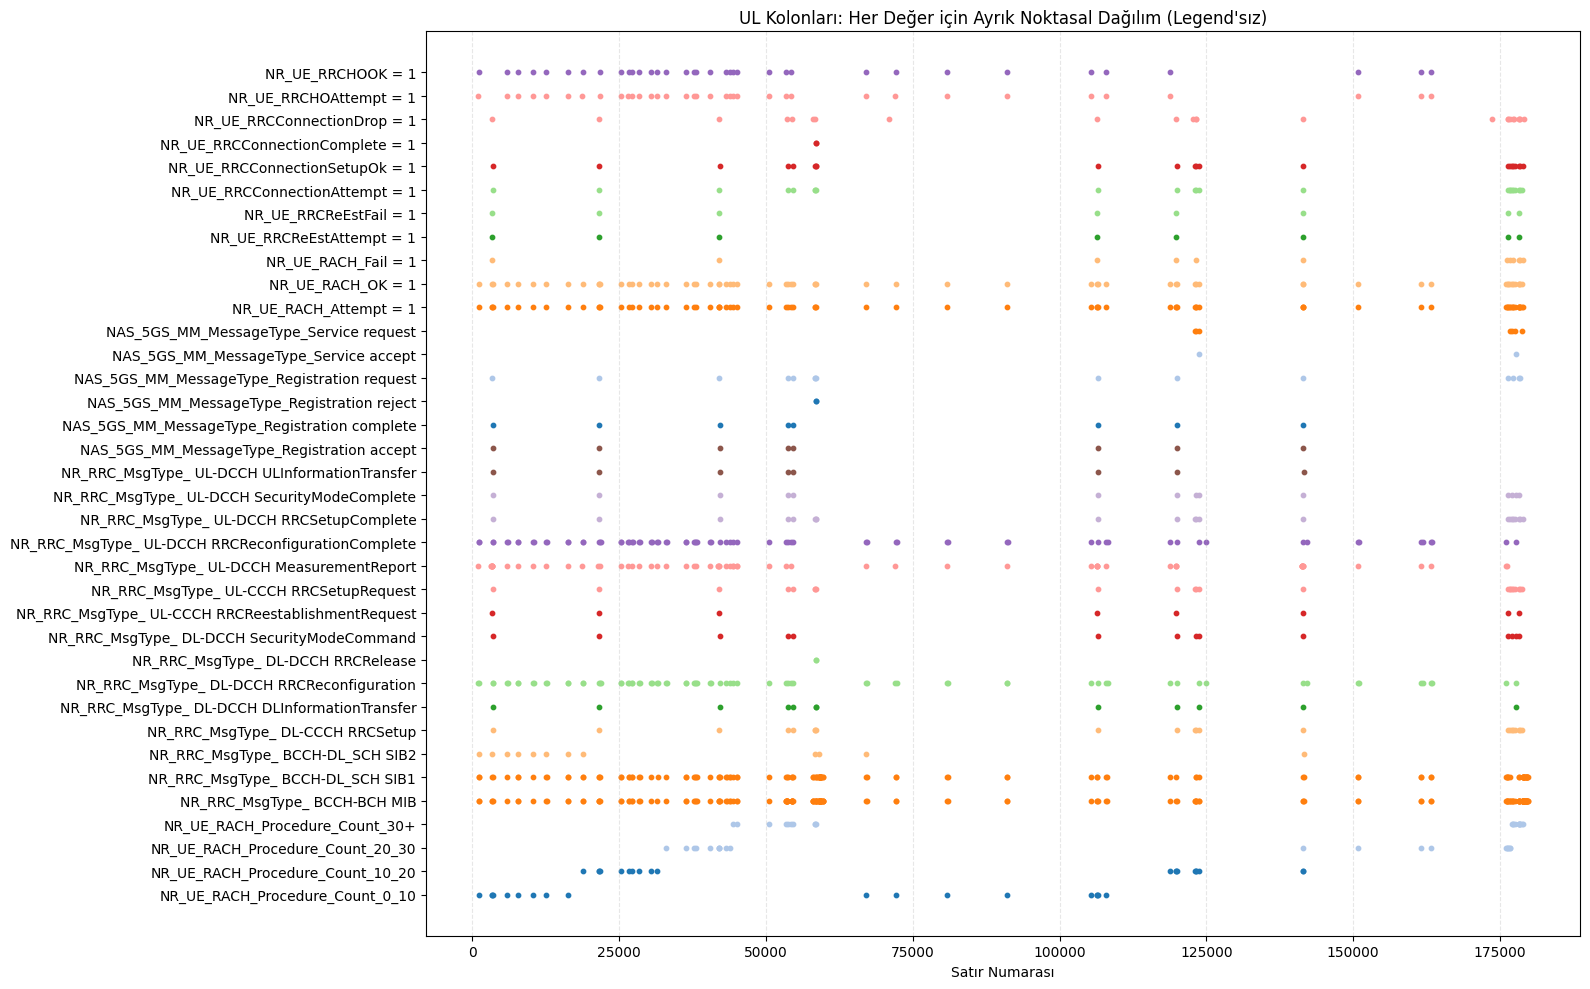

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# İlk 3 sütun grafiğe dahil edilmesin
excluded_cols = ["Time", "Longitude", "Latitude"]

# UL tarafında özel işlenecek kolonlar (DL ile aynıysa bu liste geçerlidir)
categorical_cols = ["NR_RRC_MsgType", "NAS_5GS_MM_MessageType"]
binned_col = "NR_UE_RACH_Procedure_Count"

# --- Yeni DataFrame ---
plot_df = pd.DataFrame(index=filtered_df_ul.index)

# --- 1) NR_UE_RACH_Procedure_Count için binleme ---
if binned_col in filtered_df_ul.columns:
    rach_col = pd.to_numeric(filtered_df_ul[binned_col], errors='coerce')
    plot_df[f"{binned_col}_0_10"] = ((rach_col >= 0) & (rach_col < 10)).astype(int)
    plot_df[f"{binned_col}_10_20"] = ((rach_col >= 10) & (rach_col < 20)).astype(int)
    plot_df[f"{binned_col}_20_30"] = ((rach_col >= 20) & (rach_col < 30)).astype(int)
    plot_df[f"{binned_col}_30+"] = (rach_col >= 30).astype(int)

# --- 2) Categorical kolonları one-hot encode et ---
for col in categorical_cols:
    if col in filtered_df_ul.columns:
        dummies = pd.get_dummies(filtered_df_ul[col], prefix=col)
        plot_df = pd.concat([plot_df, dummies], axis=1)

# --- 3) Diğer kolonlar: sadece 1 olanları binary olarak ekle ---
for col in filtered_df_ul.columns:
    if col not in excluded_cols + categorical_cols + [binned_col]:
        numeric_col = pd.to_numeric(filtered_df_ul[col], errors='coerce')
        binary_series = (numeric_col == 1).astype(int)
        if binary_series.sum() > 0:
            plot_df[col + " = 1"] = binary_series

# --- 4) Tamamen boş kolonları at ---
plot_df = plot_df.loc[:, plot_df.sum(axis=0) > 0]

# --- 5) SCATTER GRAFİK (LEGENDSIZ) ---
plt.figure(figsize=(16, 10))

cmap = plt.cm.get_cmap("tab20", plot_df.shape[1])
colors = [cmap(i % 20) for i in range(plot_df.shape[1])]

for i, col in enumerate(plot_df.columns):
    indices = plot_df.index[plot_df[col] == 1]
    plt.scatter(indices, [i] * len(indices), s=10, color=colors[i])

plt.yticks(range(len(plot_df.columns)), plot_df.columns)
plt.xlabel("Satır Numarası")
plt.title("UL Kolonları: Her Değer için Ayrık Noktasal Dağılım (Legend'sız)")
plt.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
from datetime import timedelta

# 1. DL ve UL için "NR_UE_RACH_Attempt == 1" olan satırları filtrele
dl_attempt_df = filtered_df_dl[
    pd.to_numeric(filtered_df_dl["NR_UE_RACH_Attempt"], errors="coerce") == 1
].copy()

ul_attempt_df = filtered_df_ul[
    pd.to_numeric(filtered_df_ul["NR_UE_RACH_Attempt"], errors="coerce") == 1
].copy()

# 2. Zaman sütunlarını datetime'a çevir
dl_attempt_df["Time"] = pd.to_datetime(dl_attempt_df["Time"], errors="coerce")
ul_attempt_df["Time"] = pd.to_datetime(ul_attempt_df["Time"], errors="coerce")

# 3. UL zamanlarını listeye çevir
ul_times = ul_attempt_df["Time"].dropna().sort_values().tolist()

# 4. DL tarafındaki her zaman için ±3 saniye içinde UL tarafında eşleşme var mı?
matched_dl = 0
for dl_time in dl_attempt_df["Time"].dropna():
    lower = dl_time - timedelta(seconds=5)
    upper = dl_time + timedelta(seconds=5)
    if any(lower <= ul_time <= upper for ul_time in ul_times):
        matched_dl += 1

# 5. Tersini de UL için hesapla
matched_ul = 0
dl_times = dl_attempt_df["Time"].dropna().sort_values().tolist()
for ul_time in ul_attempt_df["Time"].dropna():
    lower = ul_time - timedelta(seconds=5)
    upper = ul_time + timedelta(seconds=5)
    if any(lower <= dl_time <= upper for dl_time in dl_times):
        matched_ul += 1

# 6. Eşleşmeyenleri hesapla
unmatched_dl = len(dl_attempt_df) - matched_dl
unmatched_ul = len(ul_attempt_df) - matched_ul

# 7. Sonuçları yazdır
print(f"DL'de NR_UE_RACH_Attempt == 1 olan toplam satır: {len(dl_attempt_df)}")
print(f"UL'de NR_UE_RACH_Attempt == 1 olan toplam satır: {len(ul_attempt_df)}\n")

print(f"DL'deki Attempt=1 satırlarının {matched_dl} tanesi UL ile ±5 saniye içinde eşleşiyor.")
print(f"DL'deki Attempt=1 satırlarının {unmatched_dl} tanesi UL ile eşleşmiyor.\n")

print(f"UL'deki Attempt=1 satırlarının {matched_ul} tanesi DL ile ±5 saniye içinde eşleşiyor.")
print(f"UL'deki Attempt=1 satırlarının {unmatched_ul} tanesi DL ile eşleşmiyor.")


DL'de NR_UE_RACH_Attempt == 1 olan toplam satır: 57
UL'de NR_UE_RACH_Attempt == 1 olan toplam satır: 79

DL'deki Attempt=1 satırlarının 36 tanesi UL ile ±5 saniye içinde eşleşiyor.
DL'deki Attempt=1 satırlarının 21 tanesi UL ile eşleşmiyor.

UL'deki Attempt=1 satırlarının 40 tanesi DL ile ±5 saniye içinde eşleşiyor.
UL'deki Attempt=1 satırlarının 39 tanesi DL ile eşleşmiyor.
